# Programming Assignment Chapter 4: Exercise 4.4

This notebook studies local search algorithms applied to two classical artificial intelligence problems: the **8-puzzle** and the **8-queens problem**. The assignment uses the AIMA Python repository as required. The main purpose is not to implement the original algorithms from scratch, but to use/adapt AIMA's search code to perform experiments, collect results, create tables, generate figures, and analyze the behavior of each algorithm.

The algorithms compared are:

1. Steepest-ascent hill climbing
2. First-choice hill climbing
3. Hill climbing with random restart
4. Simulated annealing

The main performance measures are **search cost** and **percentage of solved problems**.


## 1. Repository Setup

This cell connects the notebook with the local copy of the `aima-python` repository. The notebook is stored in `code_groupM`, while the repository folder is stored one level above it. Adding the repository path to `sys.path` allows Python to import AIMA classes such as `Problem`, `EightPuzzle`, `hill_climbing`, and `simulated_annealing` from `search.py`.


In [16]:
# Standard modules used to access local files and folders
import sys
import os

# Absolute path to the local AIMA repository folder.
# This path should match the location where the repository was cloned.
aima_path = r"C:\Users\Diego\OneDrive\Escritorio\Personal Projects\Artificial_Inteligence_Class\HW4_Group\aima-python"

# Add the AIMA repository folder to Python's import path if it is not already there.
if aima_path not in sys.path:
    sys.path.append(aima_path)

# Import the search-related classes/functions from the AIMA repository.
from search import *

# Verify the current notebook folder and the AIMA path being used.
print("Current working directory:", os.getcwd())
print("AIMA path added:", aima_path)

Current working directory: C:\Users\Diego\OneDrive\Escritorio\Personal Projects\Artificial_Inteligence_Class\HW4_Group\code_groupM
AIMA path added: C:\Users\Diego\OneDrive\Escritorio\Personal Projects\Artificial_Inteligence_Class\HW4_Group\aima-python


## 2. Additional Libraries

These libraries are used for the experiment implementation. `random` and `math` support the local search procedures. `pandas` stores and summarizes the results. `matplotlib` creates the figures required for the report.


In [17]:
# Random number generation for random initial states and randomized algorithms
import random

# Mathematical functions used in simulated annealing
import math

# Data analysis library used to store and summarize experimental results
import pandas as pd

# Plotting library used to generate figures for the report
import matplotlib.pyplot as plt

# Optional utility for grouped data structures
from collections import defaultdict

# Optional: set a seed to make the experiment more reproducible.
random.seed(42)

## 3. Local Search Formulations for the Problems

The AIMA repository already provides general problem definitions such as `Problem` and `EightPuzzle`. However, local search algorithms need a way to evaluate how good a state is. For that reason, this section defines value functions for both problems.

For the **8-puzzle**, the value is based on the negative Manhattan distance. A smaller Manhattan distance means the state is closer to the goal, so the negative value allows hill climbing to maximize the evaluation function.

For **8-queens**, the value is based on the negative number of queen conflicts. A solution has zero conflicts, which gives the highest possible value.


In [18]:
# Goal configuration for the 8-puzzle.
# The 0 represents the blank tile.
GOAL_8PUZZLE = (1, 2, 3,
                4, 5, 6,
                7, 8, 0)


def manhattan_distance_8puzzle(state, goal=GOAL_8PUZZLE):
    """
    Compute the Manhattan distance between an 8-puzzle state and the goal state.

    The Manhattan distance adds the horizontal and vertical distance of every tile
    from its goal position. The blank tile (0) is ignored.

    A lower value means the puzzle is closer to the goal.
    """
    distance = 0

    # Only numbered tiles are considered; the blank tile is ignored.
    for tile in range(1, 9):
        current_index = state.index(tile)
        goal_index = goal.index(tile)

        current_row, current_col = divmod(current_index, 3)
        goal_row, goal_col = divmod(goal_index, 3)

        distance += abs(current_row - goal_row) + abs(current_col - goal_col)

    return distance


class EightPuzzleLocalSearch(EightPuzzle):
    """
    Local-search version of AIMA's EightPuzzle class.

    The value function returns the negative Manhattan distance. Since local search
    tries to maximize the value, the goal state has the best value: 0.
    """
    def value(self, state):
        return -manhattan_distance_8puzzle(state)


def queen_conflicts(state):
    """
    Count the number of attacking queen pairs.

    State representation:
        state[col] = row where the queen is placed in that column.

    A goal state has 0 conflicts.
    """
    conflicts = 0
    n = len(state)

    # Compare every pair of queens.
    for c1 in range(n):
        for c2 in range(c1 + 1, n):
            r1 = state[c1]
            r2 = state[c2]

            same_row = r1 == r2
            same_diagonal = abs(r1 - r2) == abs(c1 - c2)

            if same_row or same_diagonal:
                conflicts += 1

    return conflicts


class NQueensLocalSearch(Problem):
    """
    Local-search formulation of the 8-queens problem.

    The board always has one queen per column. An action moves one queen to a
    different row in the same column. The goal is to reach a state with zero conflicts.
    """
    def __init__(self, initial=None, n=8):
        self.n = n

        # If no initial board is provided, create a random one.
        if initial is None:
            initial = tuple(random.randrange(n) for _ in range(n))

        super().__init__(initial)

    def actions(self, state):
        """Return all possible moves: move one queen to a different row."""
        possible_actions = []

        for col in range(self.n):
            for row in range(self.n):
                if row != state[col]:
                    possible_actions.append((col, row))

        return possible_actions

    def result(self, state, action):
        """Return the new board after applying one queen move."""
        col, row = action
        new_state = list(state)
        new_state[col] = row
        return tuple(new_state)

    def goal_test(self, state):
        """A solution is found when no queens attack each other."""
        return queen_conflicts(state) == 0

    def value(self, state):
        """Higher value is better, so fewer conflicts gives a larger value."""
        return -queen_conflicts(state)

## 4. Instrumented Local Search Algorithms

The AIMA algorithms are the basis for this section. For the purpose of the assignment, the algorithms are instrumented to return not only the final state, but also whether the problem was solved and the **search cost**.

In this notebook, search cost is measured as the number of neighbor or candidate states evaluated by the algorithm. This makes the algorithms easier to compare experimentally.


In [19]:
def steepest_ascent_hill_climbing(problem, max_steps=1000):
    """
    Instrumented steepest-ascent hill climbing.

    At each step, this algorithm evaluates all neighbors and selects the best one.
    It stops when no neighbor improves the current state.

    Search cost = number of neighbor states evaluated.
    """
    current = problem.initial
    search_cost = 0

    for step in range(max_steps):
        # Stop immediately if the current state is already a solution.
        if problem.goal_test(current):
            return current, True, search_cost

        # Generate and evaluate all neighboring states.
        neighbors = [problem.result(current, action) for action in problem.actions(current)]
        search_cost += len(neighbors)

        if not neighbors:
            break

        # Select the neighbor with the highest value.
        neighbor = max(neighbors, key=lambda state: problem.value(state))

        # If the best neighbor is not better than the current state, stop.
        if problem.value(neighbor) <= problem.value(current):
            break

        current = neighbor

    solved = problem.goal_test(current)
    return current, solved, search_cost


def first_choice_hill_climbing(problem, max_steps=1000):
    """
    Instrumented first-choice hill climbing.

    Instead of evaluating all neighbors, this algorithm checks random neighbors and
    moves to the first one that improves the current state.

    Search cost = number of neighbor states evaluated.
    """
    current = problem.initial
    search_cost = 0

    for step in range(max_steps):
        if problem.goal_test(current):
            return current, True, search_cost

        actions = list(problem.actions(current))
        random.shuffle(actions)

        improved = False

        # Check neighbors one by one until an improvement is found.
        for action in actions:
            neighbor = problem.result(current, action)
            search_cost += 1

            if problem.value(neighbor) > problem.value(current):
                current = neighbor
                improved = True
                break

        # Stop if no improving neighbor was found.
        if not improved:
            break

    solved = problem.goal_test(current)
    return current, solved, search_cost


def random_restart_hill_climbing(problem_factory, restarts=30, max_steps=1000):
    """
    Hill climbing with random restarts.

    This algorithm repeatedly creates a new random initial state and applies
    steepest-ascent hill climbing. It stops early if a solution is found.

    Search cost = total neighbor evaluations across all restarts.
    """
    total_search_cost = 0
    final_state = None

    for restart in range(restarts):
        problem = problem_factory()
        final_state, solved, search_cost = steepest_ascent_hill_climbing(problem, max_steps=max_steps)
        total_search_cost += search_cost

        if solved:
            return final_state, True, total_search_cost

    return final_state, False, total_search_cost


def simulated_annealing_instrumented(problem, max_steps=10000, initial_temperature=20.0, cooling_rate=0.995):
    """
    Instrumented simulated annealing.

    Simulated annealing sometimes accepts worse moves early in the search. This
    behavior can help the algorithm escape local optima.

    Search cost = number of candidate states evaluated.
    """
    current = problem.initial
    search_cost = 0

    for t in range(max_steps):
        if problem.goal_test(current):
            return current, True, search_cost

        # Exponential cooling schedule.
        temperature = initial_temperature * (cooling_rate ** t)

        # Stop when the temperature becomes too small.
        if temperature < 0.001:
            break

        actions = list(problem.actions(current))

        if not actions:
            break

        # Select a random neighbor.
        action = random.choice(actions)
        neighbor = problem.result(current, action)
        search_cost += 1

        # Difference in value between the neighbor and the current state.
        delta = problem.value(neighbor) - problem.value(current)

        # Always accept an improvement.
        if delta > 0:
            current = neighbor
        else:
            # Sometimes accept a worse move depending on the temperature.
            probability = math.exp(delta / temperature)
            if random.random() < probability:
                current = neighbor

    solved = problem.goal_test(current)
    return current, solved, search_cost

## 5. Sanity Check: 8-Queens

Before running the full experiment, this cell tests the 8-queens formulation with one randomly generated board. The purpose is to verify that the state representation, conflict counter, and steepest-ascent hill climbing function are working correctly.


In [20]:
# Create one random 8-queens problem.
test_queens = NQueensLocalSearch(n=8)

print("Initial state:", test_queens.initial)
print("Initial conflicts:", queen_conflicts(test_queens.initial))

# Run steepest-ascent hill climbing on the test problem.
final_state, solved, cost = steepest_ascent_hill_climbing(test_queens)

print("Final state:", final_state)
print("Solved:", solved)
print("Final conflicts:", queen_conflicts(final_state))
print("Search cost:", cost)

Initial state: (1, 0, 4, 3, 3, 2, 1, 1)
Initial conflicts: 10
Final state: (5, 0, 6, 3, 7, 2, 4, 1)
Solved: False
Final conflicts: 1
Search cost: 280


## 6. Sanity Check: 8-Puzzle

This cell tests the 8-puzzle formulation using a simple instance that is one move away from the goal. The purpose is to confirm that the Manhattan distance, goal test, and local search procedure work as expected.


In [21]:
# A simple 8-puzzle instance that is one move away from the goal.
test_puzzle_state = (1, 2, 3,
                     4, 5, 6,
                     7, 0, 8)

test_puzzle = EightPuzzleLocalSearch(test_puzzle_state)

print("Initial state:", test_puzzle.initial)
print("Initial Manhattan distance:", manhattan_distance_8puzzle(test_puzzle.initial))

# Run steepest-ascent hill climbing on the test puzzle.
final_state, solved, cost = steepest_ascent_hill_climbing(test_puzzle)

print("Final state:", final_state)
print("Solved:", solved)
print("Final Manhattan distance:", manhattan_distance_8puzzle(final_state))
print("Search cost:", cost)

Initial state: (1, 2, 3, 4, 5, 6, 7, 0, 8)
Initial Manhattan distance: 1
Final state: (1, 2, 3, 4, 5, 6, 7, 8, 0)
Solved: True
Final Manhattan distance: 0
Search cost: 3


## 7. Random Problem Generators

The experiment requires many problem instances. For 8-queens, each instance is a random complete board with one queen per column. For 8-puzzle, each instance is generated by starting from the goal state and applying random legal moves. This guarantees that every generated puzzle is solvable.


In [22]:
def random_8queens_problem():
    """Create a random 8-queens problem instance."""
    return NQueensLocalSearch(n=8)


def random_8puzzle_state(scramble_steps=20):
    """
    Create a solvable 8-puzzle state.

    The state is produced by starting from the goal and applying random legal moves.
    Since each move is legal and reversible, the generated state is solvable.
    """
    problem = EightPuzzleLocalSearch(GOAL_8PUZZLE)
    state = GOAL_8PUZZLE

    for _ in range(scramble_steps):
        actions = list(problem.actions(state))
        action = random.choice(actions)
        state = problem.result(state, action)

    return state


def random_8puzzle_problem(scramble_steps=20):
    """Create a random solvable 8-puzzle problem instance."""
    state = random_8puzzle_state(scramble_steps=scramble_steps)
    return EightPuzzleLocalSearch(state)

## 8. Algorithm Execution Function

This helper function runs one selected algorithm on one problem instance. It stores the problem name, algorithm name, estimated initial difficulty, whether the instance was solved, the measured search cost, and the initial and final states.

For this experiment, the variable `optimal_solution_cost` is used as an estimated difficulty measure:

- For 8-puzzle, it is the Manhattan distance from the initial state to the goal.
- For 8-queens, it is the number of conflicts in the initial board.

This approximation is used to group and compare results across instances.


In [23]:
def run_algorithm(problem_name, algorithm_name, problem, problem_factory=None):
    """
    Run one algorithm on one problem instance and return the result as a dictionary.
    """
    # Estimate the initial difficulty of the instance.
    if problem_name == "8-puzzle":
        optimal_cost = manhattan_distance_8puzzle(problem.initial)
    elif problem_name == "8-queens":
        optimal_cost = queen_conflicts(problem.initial)
    else:
        optimal_cost = None

    # Select and run the requested algorithm.
    if algorithm_name == "Steepest-Ascent Hill Climbing":
        final_state, solved, search_cost = steepest_ascent_hill_climbing(problem)

    elif algorithm_name == "First-Choice Hill Climbing":
        final_state, solved, search_cost = first_choice_hill_climbing(problem)

    elif algorithm_name == "Random-Restart Hill Climbing":
        final_state, solved, search_cost = random_restart_hill_climbing(
            problem_factory,
            restarts=30
        )

    elif algorithm_name == "Simulated Annealing":
        final_state, solved, search_cost = simulated_annealing_instrumented(problem)

    else:
        raise ValueError("Unknown algorithm")

    # Return all relevant information in a format that can be converted to a DataFrame.
    return {
        "problem": problem_name,
        "algorithm": algorithm_name,
        "optimal_solution_cost": optimal_cost,
        "solved": solved,
        "search_cost": search_cost,
        "initial_state": problem.initial,
        "final_state": final_state
    }

## 9. Full Experiment

This cell runs the four algorithms on randomly generated instances of the 8-puzzle and 8-queens problems. Each result is stored in a list and then converted into a pandas DataFrame.

The number of instances can be increased for a stronger experiment, but 50 instances per problem provides a reasonable initial test while keeping runtime manageable.


In [24]:
# Algorithms included in the comparison.
algorithms = [
    "Steepest-Ascent Hill Climbing",
    "First-Choice Hill Climbing",
    "Random-Restart Hill Climbing",
    "Simulated Annealing"
]

# This list will store all individual experiment results.
results = []

# Number of random instances generated for each problem.
number_of_instances = 50

for i in range(number_of_instances):

    # --- 8-Queens experiment ---
    queens_problem = random_8queens_problem()

    for algorithm in algorithms:
        result = run_algorithm(
            problem_name="8-queens",
            algorithm_name=algorithm,
            problem=queens_problem,
            problem_factory=random_8queens_problem
        )
        results.append(result)

    # --- 8-Puzzle experiment ---
    puzzle_problem = random_8puzzle_problem(scramble_steps=20)

    for algorithm in algorithms:
        result = run_algorithm(
            problem_name="8-puzzle",
            algorithm_name=algorithm,
            problem=puzzle_problem,
            problem_factory=lambda: random_8puzzle_problem(scramble_steps=20)
        )
        results.append(result)

# Convert the list of dictionaries into a table.
df_results = pd.DataFrame(results)

# Display the first rows of the raw results.
df_results.head()

,problem,algorithm,optimal_solution_cost,solved,search_cost,initial_state,final_state
0,8-queens,Steepest-Ascent Hill Climbing,11,True,280,"(6, 0, 0, 1, 3, 3, 0, 3)","(6, 2, 7, 1, 4, 0, 5, 3)"
1,8-queens,First-Choice Hill Climbing,11,False,128,"(6, 0, 0, 1, 3, 3, 0, 3)","(6, 4, 0, 7, 5, 2, 5, 1)"
2,8-queens,Random-Restart Hill Climbing,11,True,1512,"(6, 0, 0, 1, 3, 3, 0, 3)","(3, 1, 6, 2, 5, 7, 4, 0)"
3,8-queens,Simulated Annealing,11,True,1880,"(6, 0, 0, 1, 3, 3, 0, 3)","(3, 5, 7, 2, 0, 6, 4, 1)"
4,8-puzzle,Steepest-Ascent Hill Climbing,10,True,27,"(4, 1, 2, 7, 8, 3, 0, 6, 5)","(1, 2, 3, 4, 5, 6, 7, 8, 0)"


## 10. Raw Results Table

This table contains one row per algorithm execution. It allows inspection of the initial state, final state, whether the instance was solved, and the search cost.


In [25]:
df_results

,problem,algorithm,optimal_solution_cost,solved,search_cost,initial_state,final_state
0,8-queens,Steepest-Ascent Hill Climbing,11,True,280,"(6, 0, 0, 1, 3, 3, 0, 3)","(6, 2, 7, 1, 4, 0, 5, 3)"
1,8-queens,First-Choice Hill Climbing,11,False,128,"(6, 0, 0, 1, 3, 3, 0, 3)","(6, 4, 0, 7, 5, 2, 5, 1)"
2,8-queens,Random-Restart Hill Climbing,11,True,1512,"(6, 0, 0, 1, 3, 3, 0, 3)","(3, 1, 6, 2, 5, 7, 4, 0)"
3,8-queens,Simulated Annealing,11,True,1880,"(6, 0, 0, 1, 3, 3, 0, 3)","(3, 5, 7, 2, 0, 6, 4, 1)"
4,8-puzzle,Steepest-Ascent Hill Climbing,10,True,27,"(4, 1, 2, 7, 8, 3, 0, 6, 5)","(1, 2, 3, 4, 5, 6, 7, 8, 0)"
...,...,...,...,...,...,...,...
395,8-queens,Simulated Annealing,10,True,1129,"(3, 4, 2, 2, 6, 5, 6, 2)","(3, 6, 2, 7, 1, 4, 0, 5)"
396,8-puzzle,Steepest-Ascent Hill Climbing,0,True,0,"(1, 2, 3, 4, 5, 6, 7, 8, 0)","(1, 2, 3, 4, 5, 6, 7, 8, 0)"
397,8-puzzle,First-Choice Hill Climbing,0,True,0,"(1, 2, 3, 4, 5, 6, 7, 8, 0)","(1, 2, 3, 4, 5, 6, 7, 8, 0)"
398,8-puzzle,Random-Restart Hill Climbing,0,True,14,"(1, 2, 3, 4, 5, 6, 7, 8, 0)","(1, 2, 3, 4, 5, 6, 7, 8, 0)"


## 11. Number of Experimental Runs

This cell checks the size of the results table. With 50 instances, 2 problems, and 4 algorithms, the expected number of rows is 400.


In [26]:
df_results.shape

(400, 7)

## 12. Summary by Problem, Algorithm, and Difficulty

This table groups the results by problem, algorithm, and estimated initial difficulty. It computes the percentage of solved instances and the average search cost for each group.


In [27]:
summary = df_results.groupby(
    ["problem", "algorithm", "optimal_solution_cost"]
).agg(
    percentage_solved=("solved", "mean"),
    average_search_cost=("search_cost", "mean"),
    number_of_trials=("solved", "count")
).reset_index()

# Convert from proportion to percentage.
summary["percentage_solved"] = summary["percentage_solved"] * 100

summary.head()

,problem,algorithm,optimal_solution_cost,percentage_solved,average_search_cost,number_of_trials
0,8-puzzle,First-Choice Hill Climbing,0,100.000000,0.000000,3
1,8-puzzle,First-Choice Hill Climbing,2,100.000000,3.000000,3
2,8-puzzle,First-Choice Hill Climbing,4,57.142857,6.000000,7
3,8-puzzle,First-Choice Hill Climbing,6,75.000000,9.750000,16
4,8-puzzle,First-Choice Hill Climbing,8,54.545455,11.272727,11


## 13. Overall Summary by Problem and Algorithm

This table summarizes the general behavior of each algorithm on each problem. It reports the percentage solved, average search cost, median search cost, and total number of trials.


In [28]:
overall_summary = df_results.groupby(
    ["problem", "algorithm"]
).agg(
    percentage_solved=("solved", "mean"),
    average_search_cost=("search_cost", "mean"),
    median_search_cost=("search_cost", "median"),
    number_of_trials=("solved", "count")
).reset_index()

# Convert from proportion to percentage.
overall_summary["percentage_solved"] = overall_summary["percentage_solved"] * 100

overall_summary

,problem,algorithm,percentage_solved,average_search_cost,median_search_cost,number_of_trials
0,8-puzzle,First-Choice Hill Climbing,62.0,8.74,8.0,50
1,8-puzzle,Random-Restart Hill Climbing,100.0,17.44,17.0,50
2,8-puzzle,Simulated Annealing,16.0,1669.54,1976.0,50
3,8-puzzle,Steepest-Ascent Hill Climbing,68.0,13.46,15.0,50
4,8-queens,First-Choice Hill Climbing,12.0,93.34,87.0,50
5,8-queens,Random-Restart Hill Climbing,100.0,1528.80,1344.0,50
6,8-queens,Simulated Annealing,86.0,1240.92,1100.0,50
7,8-queens,Steepest-Ascent Hill Climbing,20.0,211.68,224.0,50


## 14. Figure 1: Percentage Solved vs. Initial Difficulty

This figure compares how often each algorithm solves the problem as the estimated initial difficulty changes. A higher percentage indicates that the algorithm is more reliable for that difficulty level.


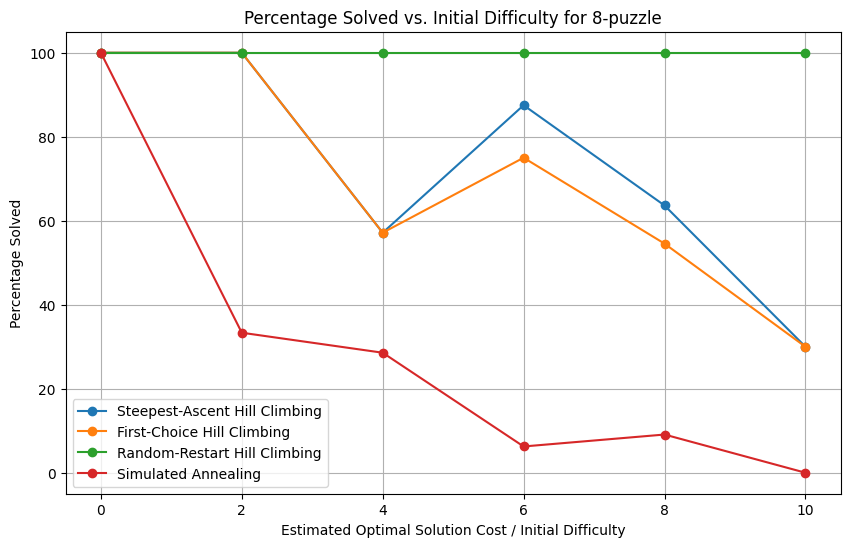

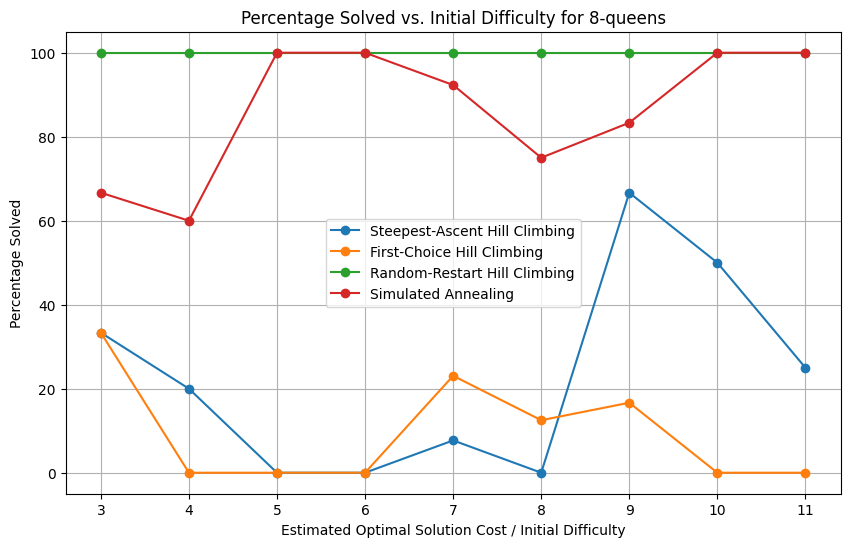

In [33]:
for problem_name in summary["problem"].unique():
    subset_problem = summary[summary["problem"] == problem_name]

    plt.figure(figsize=(10, 6))

    for algorithm in algorithms:
        subset_algorithm = subset_problem[subset_problem["algorithm"] == algorithm]
        plt.plot(
            subset_algorithm["optimal_solution_cost"],
            subset_algorithm["percentage_solved"],
            marker="o",
            label=algorithm
        )

    plt.xlabel("Estimated Optimal Solution Cost / Initial Difficulty")
    plt.ylabel("Percentage Solved")
    plt.title(f"Percentage Solved vs. Initial Difficulty for {problem_name}")
    plt.legend()
    plt.grid(True)
    plt.show()

## 15. Figure 2: Search Cost vs. Initial Difficulty

This figure compares the average search cost of each algorithm as the estimated initial difficulty changes. A lower search cost means the algorithm evaluated fewer states on average.


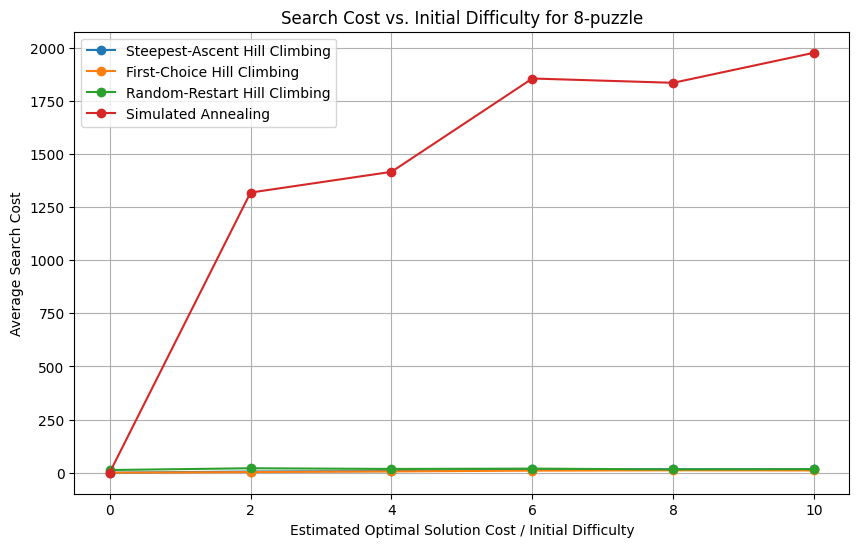

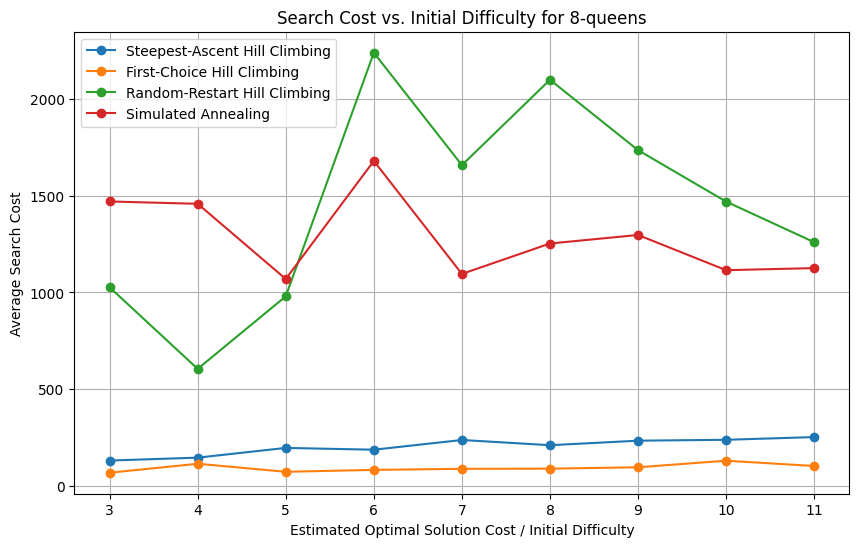

In [32]:
for problem_name in summary["problem"].unique():
    subset_problem = summary[summary["problem"] == problem_name]

    plt.figure(figsize=(10, 6))

    for algorithm in algorithms:
        subset_algorithm = subset_problem[subset_problem["algorithm"] == algorithm]
        plt.plot(
            subset_algorithm["optimal_solution_cost"],
            subset_algorithm["average_search_cost"],
            marker="o",
            label=algorithm
        )

    plt.xlabel("Estimated Optimal Solution Cost / Initial Difficulty")
    plt.ylabel("Average Search Cost")
    plt.title(f"Search Cost vs. Initial Difficulty for {problem_name}")
    plt.legend()
    plt.grid(True)
    plt.show()

## 16. Exporting Results

The following cell exports the raw results and summary tables as CSV files. These files are used to verify the numerical results and use them for the report or presentation.


In [31]:
# Export raw and summarized results to CSV files.
df_results.to_csv("hw4_exercise_4_4_raw_results.csv", index=False)
summary.to_csv("hw4_exercise_4_4_summary_results.csv", index=False)
overall_summary.to_csv("hw4_exercise_4_4_overall_summary.csv", index=False)

print("CSV files exported successfully.")

CSV files exported successfully.


## 17. Discussion

The results should be interpreted by comparing both reliability and cost. Simple hill climbing methods can be fast, but they may fail when the search reaches a local optimum, plateau, or shoulder. First-choice hill climbing may evaluate fewer neighbors because it accepts the first improving move, but its performance depends strongly on the random order of the neighbors.

Random-restart hill climbing usually improves the percentage of solved problems because it tries several independent initial states. However, this improvement comes with a higher search cost, since multiple hill-climbing attempts may be performed.

Simulated annealing can escape some local optima by accepting worse moves with a probability that decreases over time. Its performance depends on the cooling schedule. If the temperature decreases too quickly, it behaves more like hill climbing. If the temperature decreases too slowly, the search cost may increase.

Overall, the relationship between initial difficulty and algorithm performance can be observed in the figures. As the estimated difficulty increases, the percentage solved may decrease and the average search cost may increase, depending on the algorithm and the problem structure.


## 18. Conclusion

This experiment compared four local search algorithms on the 8-puzzle and 8-queens problems. The results show that different local search strategies involve tradeoffs between reliability and search cost. Hill climbing variants are simple and efficient but can get trapped in local optima. Random restarts increase the probability of finding a solution, while simulated annealing introduces controlled randomness to escape poor local decisions.

The experiment also shows the importance of measuring both the percentage of solved instances and the search cost. An algorithm that solves more instances may require more evaluations, while a cheaper algorithm may fail more often.


## References

[1] S. Russell and P. Norvig, *Artificial Intelligence: A Modern Approach*, 4th ed. Hoboken, NJ, USA: Pearson, 2021.

[2] AIMA Code, “aima-python,” GitHub. [Online]. Available: https://github.com/aimacode/aima-python. [Accessed: Apr. 27, 2026].
